# 5. Tutorial

**Course:** Power Electronics Devices and Components  

## 5.1. Coding solutions for Wide-Bandgap Devices

Following material parameter are given for 3 semiconductor types:

|Material|$E_g$               |$E_{\mathrm{crit}}$    |
|:--------|:-----------------:|:---------------------:|
| Si:     | $1.1~\mathrm{eV}$ | $0.3\~\mathrm{MV/cm}$ |
| 4H-SiC: | $3.2~\mathrm{eV}$ | $2.8~\mathrm{MV/cm}$  |
| GaNWe:  | $3.4~\mathrm{eV}$ | $3.3~\mathrm{MV/cm}$  |

Assume the voltage of $V_\mathrm{B} = 1200~\mathrm{V}$ for the w_drift calculation.

5.1.1 Import necessary modules (numpy as np and matplotlib.pyplot as plt) and create a map of the material.

5.1.2 Print the map as table.

5.1.3 Create a function 'calculate_w_drift' with input parameter $E_\mathrm{crit}$, which calculates the $W_\mathrm{drift}$ for each material,
      at given voltage $V_\mathrm{B}$.

5.1.4 Create a function 'calculate_r_proxy' with input parameter $E_\mathrm{crit}$, which calculates the $R_{\mathrm{drift,proxy}}$ for each material,
      at given voltage $V_\mathrm{B}$ according $R_{\mathrm{drift,proxy}}=\frac{W_\mathrm{drift}}{E_\mathrm{crit}}$

5.1.5 Create a function 'calculate_r_normlized_proxy' with input parameter $R_{\mathrm{drift,proxy}}$ and $R_{\mathrm{ref_proxy}}$, 
      which calculates the normalized $R_{\mathrm{norm}}$ for each material.

5.1.6 Plot the map as bar plot for each material ($E_g$  and $E_{\mathrm{crit}}$ per material) 

5.1.7 Plot the drift reqion thickness as bar plot for each material.

5.1.8 Plot the normalized proxy resistance normalized to material Si.

5.1.9 Interpretate the results due to drift thickness region and the consequence.


Material | Eg in eV         | E_crit in V      | w_drift in m     | r_proxy          | r_norm_proxy      
-------------------------------------------------------------------------------------------------------
Si       | 1.1              | 300000           | 0.00400          | 1.33333e-08      | 1.000           
4H-SiC   | 3.2              | 2800000          | 0.00043          | 1.53061e-10      | 0.011           
GaNWe    | 3.4              | 3300000          | 0.00036          | 1.10193e-10      | 0.008           


<Figure size 800x500 with 0 Axes>

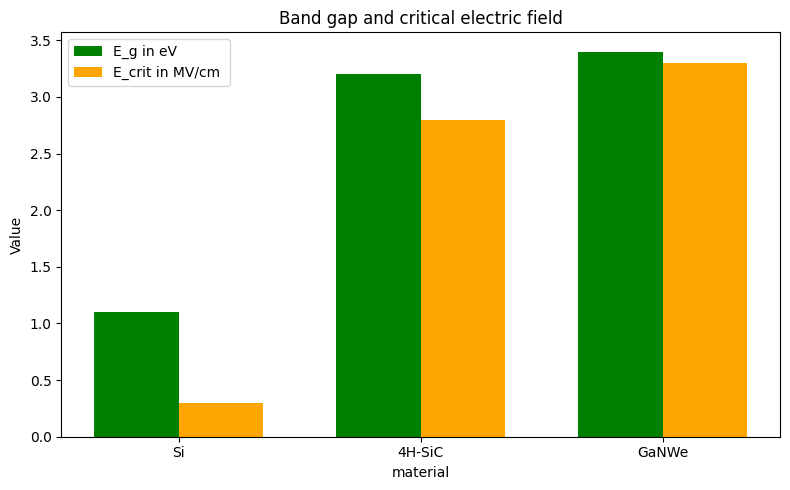

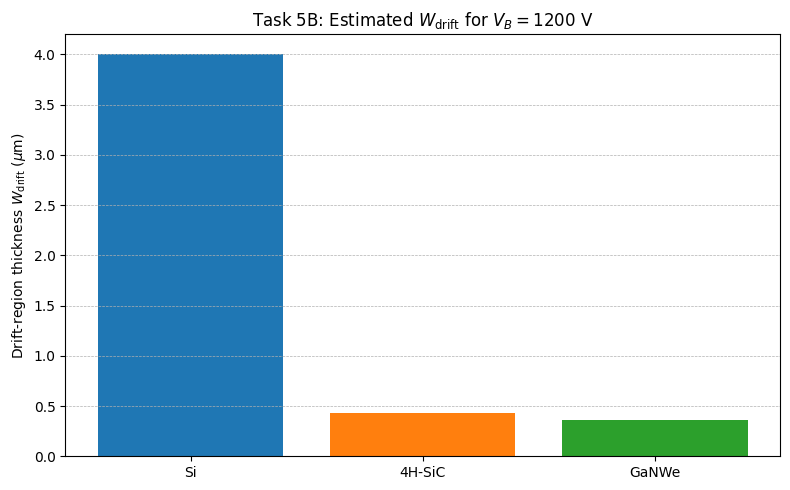

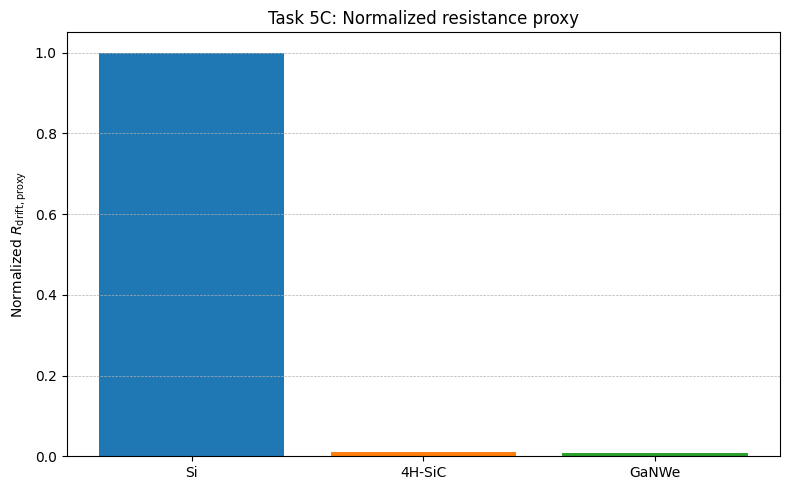

In [ ]:
# Subtask 5.1.1 Import necessary modules (numpy as np and matplotlib.pyplot as plt) and create a map of the material.

import numpy as np
import matplotlib.pyplot as plt

# Create color list and marker list
color_list = ['red', 'blue', 'green', 'orange', 'black', 'cyan', 'magenta', 'purple']
marker_list=['o', '.', '+', '_', '*', 's', 'D', '^', 'v', '<', '>', 'p', 'h', 'H', 'x', 'D', 'd', 'P', 'X']

# ---------------------------------------------------------------------
# Fixed constants and map for the tutorial
# ---------------------------------------------------------------------

# Unit: Eg [eV],  E_crit[V/cm]
materials = {
    'Si':  {'Eg': 1.1, 'E_crit': 0.3e6},
    '4H-SiC': {'Eg': 3.2, 'E_crit': 2.8e6},
    'GaNWe': {'Eg': 3.4, 'E_crit': 3.3e6}
}

# Voltage
V_b = 1200.0  # V

# Subtask 5.1.3 Create a function 'calculate_w_drift' with input parameter E_crit

def calculate_w_drift(act_E_crit):
    # Calculate w_drift with given V_b
    w_drift = V_b / act_E_crit
    return w_drift

# Subtask 5.1.4 Create a function 'calculate_r_proxy' with input parameter E_crit and w_drift
def calculate_r_proxy(act_w_drift, act_E_crit):
    # Calculate r_proxy with given V_b
    r_proxy = act_w_drift / act_E_crit
    return r_proxy


# Subtask 5.1.5 Create a function 'calculate_r_normlized_proxy' with input parameter r_proxy  and r_ref_proxy
def calculate_r_normlized_proxy(act_r_proxy, act_r_ref_proxy):
    # Calculate r_proxy with given V_b
    r_norm_proxy = act_r_proxy / act_r_ref_proxy
    return r_norm_proxy


if __name__ == "__main__":
  
    plt.figure(figsize=(8, 5))
    # Calculate w_drift, r_proxy and r_norm_proxy (Normalized to SI) for each material
    # Loop over dictionary
    for material in materials:
        # Get E_crit
        E_crit=materials[material]['E_crit']
        # Calculate w_drift
        w_drift = calculate_w_drift(E_crit)
        # Add it to the dictionary
        materials[material]["w_drift"] = w_drift
        # Calculate r_proxy
        r_proxy = calculate_r_proxy(w_drift, E_crit)
        # Add it to the dictionary
        materials[material]["r_proxy"] = r_proxy
        # Calculate r_norm_proxy
        r_norm_proxy = calculate_r_proxy(r_proxy, materials["Si"]["r_proxy"])
        # Add it to the dictionary
        materials[material]["r_norm_proxy"] = r_norm_proxy

    # print result (5.1.2)
    layout_cell = 16
    layout_name = 8

    # Loop over materials
    header = f"{'Material':<{layout_name}} | {'Eg in eV':<{layout_cell}} | {'E_crit in V':<{layout_cell}} | {'w_drift in m':<{layout_cell}}"
    header = header  + f" | {'r_proxy':<{layout_cell}} | {'r_norm_proxy':<{layout_cell}}  "
    header = header  + "\n-------------------------------------------------------------------------------------------------------"

    print(header)
    for i, material in enumerate(materials):
        # Plot bar for Eg and E_crit at the same x-coordinate
        plotline = f"{material:<{layout_name}} | {materials[material]['Eg']:<{layout_cell}} | {materials[material]['E_crit']:<{layout_cell}.0f}"
        plotline = plotline + f" | {materials[material]['w_drift']:<{layout_cell}.5f} | {materials[material]['r_proxy']:<{layout_cell}.5e}"
        plotline = plotline + f" | {materials[material]['r_norm_proxy']:<{layout_cell}.3f}"
        print(plotline)

    # Subtask 5.1.6 Plot the map as bar plot for each material ($E_g$  and $E_{\mathrm{crit}}$ per material) 
    x_positions = range(len(materials))  # Position per material
    bar_width = 0.35  # Width of the bars

    plt.figure(figsize=(8, 5))
    # Loop over materials
    for i, material in enumerate(materials):
        # Plot bar for Eg and E_crit at the same x-coordinate
        plt.bar(i - bar_width/2, materials[material]['Eg'], width=bar_width, label="E_g in eV" if i == 0 else "", color=color_list[2])
        plt.bar(i + bar_width/2, materials[material]['E_crit']/1e6, width=bar_width, label="E_crit in MV/cm " if i == 0 else "", color=color_list[3])

    # Add legend and title
    plt.xlabel("material")
    plt.ylabel("Value")
    plt.title("Band gap and critical electric field")
    # Add material name at bar position
    plt.xticks(x_positions, materials)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Subtask 5.1.7 Plot the drift reqion thickness as bar plot for each material.
    plt.figure(figsize=(8, 5))
    # Loop over dictionary
    for material in materials:
        # Get w-drift in micrometer
        w_drift_um = materials[material]["w_drift"] * 1000
        # Add bar
        plt.bar(material, w_drift_um)

    plt.ylabel(r'Drift-region thickness $W_{\mathrm{drift}}$ ($\mu$m)')
    plt.title(r'Task 5B: Estimated $W_{\mathrm{drift}}$ for $V_B = 1200$ V')
    plt.grid(True, axis='y', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()



    # Subtask 5.1.8 Plot the normalized proxy resistance normalized to material Si.
    plt.figure(figsize=(8, 5))
    # Plot
    # Loop over dictionary
    for material in materials:
        # Get normalized r-proxy
        r_norm_proxy = materials[material]["r_norm_proxy"]
        # Add bar
        plt.bar(material, r_norm_proxy)

    plt.ylabel(r'Normalized $R_{\mathrm{drift,proxy}}$')
    plt.title(r'Task 5C: Normalized resistance proxy')
    plt.grid(True, axis='y', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()


### Subtask 5.1.9 Interpretate the results due to drift thickness region and the consequence.

$$
\begin{align*}
  \text{Silicon needs the thickest drift region:} \quad &W_\mathrm{drift,Si} = 40.0~\mu\mathrm{m} \\
  \text{4H-SiC needs only about:} \quad &W_\mathrm{drift,SiC} \approx 4.29\mu\mathrm{m}  \\
  \text{GaN needs about:} \quad &W_\mathrm{drift,GaN} \approx 3.64\mu\mathrm{m}
\end{align*}
$$


The normalized resistance proxy becomes:
- Si: $1.000$
- 4H-SiC: $\approx 0.0115$
- GaN: $\approx 0.00826$

So both SiC and GaN drastically reduce the drift-region burden compared with silicon.

A suitable short answer to the final conceptual question is:

- SiC and GaN both outperform silicon at the material level, but SiC is typically pushed toward high-voltage/high-temperature power conversion, whereas GaN is often pushed toward very high switching frequency and compact high-power-density designs.

## Task 5.2 — SiC MOSFET FOM and loss comparison

Tutorial devices:

|Device|$R_{\mathrm{DS(on)}}$|$Q_\mathrm{G}$        |$C_\mathrm{oss}$ |
|:-----|:-------------------:|:--------------------:|:---------------:|
| A:   | $45~\mathrm{m}\Omega$ | $110~\mathrm{nC}$  |120~\mathrm{pF}  |
| B:   | $60~\mathrm{m}\Omega$ | $ 70~\mathrm{nC}$  | 80~\mathrm{pF}  |
| C:   | $35~\mathrm{m}\Omega$ | $180~\mathrm{nC}$  |180~\mathrm{pF}  |


Converter conditions:
- $I_\mathrm{rms} = 18~\mathrm{A}$
- $V_\mathrm{DRV} = 18~\mathrm{V}$
- $f_\mathrm{s} =   100~\mathrm{kHz}$

We use $\qquad P_C = I_{\mathrm{rms}}^2 R_{\mathrm{DS(on)}} \quad \text{and} \quad P_G = Q_G V_{\mathrm{DRV}} f_\mathrm{s}$

and the two FOMs $\quad FOM_1 = R_{\mathrm{DS(on)}}Q_G \quad \text{and} \quad FOM_2 = R_{\mathrm{DS(on)}}C_{\mathrm{oss}}$.

5.2.1 Create a map of the material and add constant variables for the constant values.

5.2.2 Print the map as table.

5.2.3 Create a functions 'calculate_P_cond' to calculate conduction power loss (from rms-current and on-resistant) and 
'calculate_P_sw' switching power loss (from gate charge).

5.2.4 Create a functions 'get_FOM_1_nC' to calculate the value according equation for $FOM_1$ and 'get_FORM2_pF' to calculate the 
value according equation for $FOM_2$.

5.2.5 Plot the conduction loss and gate driver loss as bar plot for each device.

5.2.6 Plot the results of the 2 FOMs as bar plot for each device.

5.2.7 Plot the normalized proxy resistance normalized to material Si.

5.2.8 Interpetate the result according lowest conduction loss, lowest gate-drive burden and best hard-switching-oriented FOMs.

5.2.9 Evaluate if one or both FOMs are sufficient for device selection. Please Justify your answer.

         | Rdson in Ohm | P_cond in W  | P_gd in W    | FOM_1        | FOM_2         
-------------------------------------------------------------------------------------------------------
Device A | 0.045        | 15           | 0.198        | 4950         | 5400        
Device B | 0.06         | 19           | 0.126        | 4200         | 4800        
Device C | 0.035        | 11           | 0.324        | 6300         | 6300        


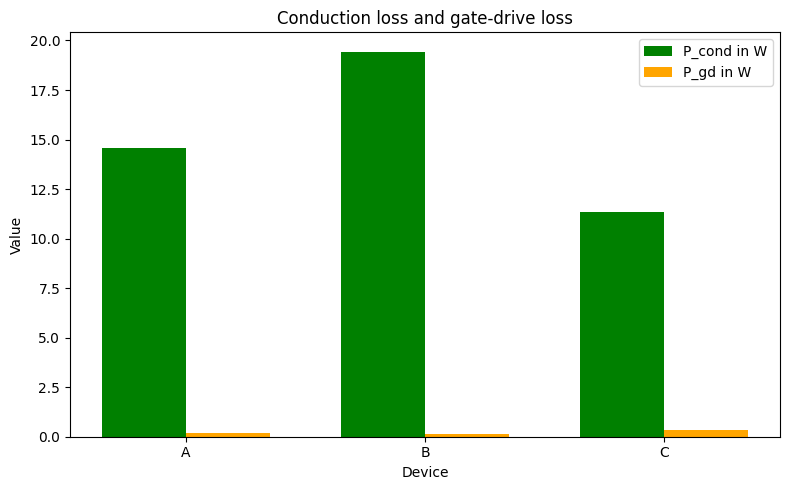

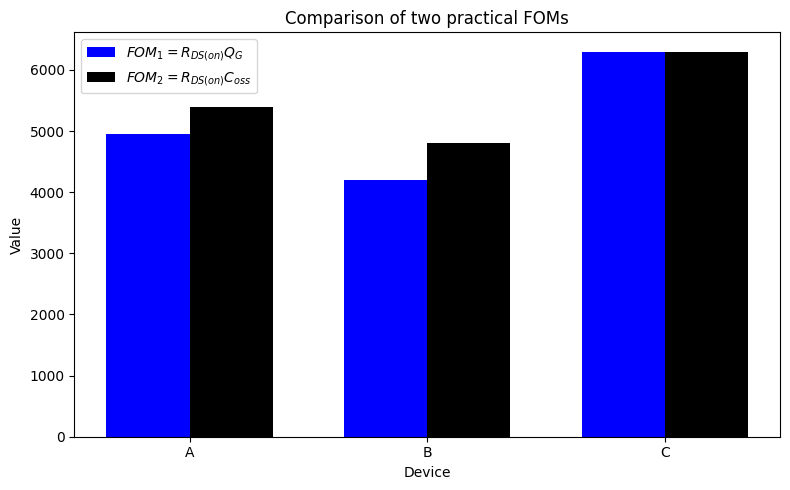

In [ ]:
# ---------------------------------------------------------------------
# Fixed constants and map for the tutorial
# ---------------------------------------------------------------------

# Subtask 5.2.1 Create a map of devices and add constant variables for the constant values.

# Device map: Units-> Rdon [Ohm],  Qc [C], Coss [F]
devices = {
    'A':  {'Rdson': 45e-3, 'Qg': 110e-9, 'Coss': 120e-12},
    'B': {'Rdson': 60e-3, 'Qg': 70e-9, 'Coss': 80e-12},
    'C': {'Rdson': 35e-3, 'Qg': 180e-9, 'Coss': 180e-12}
}

# Constants
I_rms = 18   # 18 A
V_drv = 18   # 18 V
f_s = 100e3  # 100kHz

# Subtask 5.2.3 Create a functions 'calculate_P_cond' to calculate conduction power loss
# and 'calculate_P_sw' tp calculate the switching power loss (from gate charge).

def calculate_P_cond(act_rdson):
    P_cond = I_rms**2 * act_rdson
    return P_cond

def calculate_P_gd(act_Qg_C):
    P_gd = V_drv * f_s * act_Qg_C
    return P_gd

# Subtask 5.2.4 Create a functions 'get_FOM_1_nC' to calculate the value according equation for $FOM_1$ 
# and 'get_FORM2_pF' to calculate the value according equation for $FOM_2$.

def get_FOM_1_nC(act_rdson, act_Qg_g):
    FOM1_mohm_nC = act_rdson * act_Qg_g * 1e12
    return FOM1_mohm_nC

def get_FOM_2_pF(act_rdson, act_Coss):
    FOM2_mohm_pF = act_rdson * act_Coss  * 1e15
    return FOM2_mohm_pF

if __name__ == "__main__":
    
    # Calculate P_cond, P_sw, FOM_1 and FOM_2 for each device
    # Loop over devices
    for device in devices:
        # Get rdson
        Rdson = devices[device]['Rdson']
        # Calculate conduction power loss
        P_cond = calculate_P_cond(Rdson)
        # Add it to the dictionary
        devices[device]["P_cond"] = P_cond
        # Calculate FOM_1_nC
        FOM_1 = get_FOM_1_nC(Rdson, devices[device]['Qg'])
        # Add it to the dictionary
        devices[device]["FOM_1"] = FOM_1
        # Calculate FOM_2_pf
        FOM_2 = get_FOM_2_pF(Rdson, devices[device]['Coss'])
        # Add it to the dictionary
        devices[device]["FOM_2"] = FOM_2
        # Calculate switching power loss
        P_gd = calculate_P_gd(devices[device]['Qg'])     
        # Add it to the dictionary
        devices[device]["P_gd"] = P_gd

    # Subtask 5.2.2 Print the map as table.
    layout_cell = 12
    layout_name = 8

    # Loop over devices
    header = f"{'':<{layout_name}} | {'Rdson in Ohm':<{layout_cell}} | {'P_cond in W':<{layout_cell}} | {'P_gd in W':<{layout_cell}}"
    header = header  + f" | {'FOM_1':<{layout_cell}} | {'FOM_2':<{layout_cell}}  "
    header = header  + "\n-------------------------------------------------------------------------------------------------------"

    print(header)
    # Loop over devices    
    for device in devices:
        # Assemble the line content per device
        plotline = f"Device {device:<{layout_name-7}} | {devices[device]['Rdson']:<{layout_cell}} | {devices[device]['P_cond']:<{layout_cell}.0f}"
        plotline = plotline + f" | {devices[device]['P_gd']:<{layout_cell}.3f} | {devices[device]['FOM_1']:<{layout_cell}.0f}"
        plotline = plotline + f" | {devices[device]['FOM_2']:<{layout_cell}.0f}"
        print(plotline)


    # Subtask 5.2.5 Plot the conduction loss and gate driver loss as bar plot for each device

    x_positions = range(len(devices)) # Position per device
    bar_width = 0.35  # Width of the bars

    plt.figure(figsize=(8, 5))
    # Loop over devices
    for i, device in enumerate(devices):
        # Plot bar for P_cond and P_gd for one device at the same x-coordinate
        plt.bar(i - bar_width/2, devices[device]['P_cond'], width=bar_width, label="P_cond in W" if i == 0 else "", color=color_list[2])
        plt.bar(i + bar_width/2, devices[device]['P_gd'], width=bar_width, label="P_gd in W" if i == 0 else "", color=color_list[3])

    # Add legend and title
    plt.xlabel("Device")
    plt.ylabel("Value")
    plt.title("Conduction loss and gate-drive loss")
    # Add device name at bar position
    plt.xticks(x_positions, devices)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    # Loop over devices
    for i, device in enumerate(devices):
        # Plot bar for FOM_1 and FOM_2 for one device at the same x-coordinate
        plt.bar(i - bar_width/2, devices[device]['FOM_1'], width=bar_width, label=r'$FOM_1 = R_{DS(on)}Q_G$' if i == 0 else "", color=color_list[1])
        plt.bar(i + bar_width/2, devices[device]['FOM_2'], width=bar_width, label=r'$FOM_2 = R_{DS(on)}C_{oss}$' if i == 0 else "", color=color_list[4])

    # Add legend and title
    plt.xlabel("Device")
    plt.ylabel("Value")
    plt.title("Comparison of two practical FOMs")
    # Add device name at bar position
    plt.xticks(x_positions, devices)
    plt.legend()
    plt.tight_layout()
    plt.show()


### Task 5.2.8+9 — Interpretation


#### Subtask 5.2.8 Interpetate the result according lowest conduction loss, lowest gate-drive burden and best hard-switching-oriented FOMs.

The computed values are:

- **Device A**
  - $P_\mathrm{C} = 14.58~\mathrm{W}$
  - $P_\mathrm{G} = 0.198~\mathrm{W}$
  - $\text{FOM}_1 = 4950~\mathrm{m} \Omega \cdot \mathrm{nC}$
  - $\text{FOM}_2 = 5400~\mathrm{m} \Omega\cdot \mathrm{pF}$

- **Device B**
  - $P_\mathrm{C} = 19.44~\mathrm{W}$
  - $P_\mathrm{G} = 0.126~\mathrm{W}$
  - $\text{FOM}_1 = 4200\,\mathrm{m} \Omega \cdot \mathrm{nC}$
  - $\text{FOM}_2 = 4800\,\mathrm{m} \Omega\cdot \mathrm{pF}$

- **Device C**
  - $P_\mathrm{C} = 11.34~\mathrm{W}$
  - $P_\mathrm{G} = 0.324~\mathrm{W}$
  - $\text{FOM}_1 = 6300~\mathrm{m} \Omega \cdot \mathrm{nC}$
  - $\text{FOM}_2 = 6300~\mathrm{m} \Omega\cdot \mathrm{pF}$

##### Ranking
- **Lowest conduction loss:** Device C
- **Lowest gate-drive burden:** Device B
- **Best hard-switching-oriented FOMs:** Device B

#### Subtask 5.2.9 Evaluate if one or both FOMs are sufficient for device selection. Please Justify your answer.

##### Final design conclusion
No single FOM is sufficient by itself:
- Device C looks best in conduction,
- Device B looks best in gate-drive burden and switching-oriented FOM,
- Device A is intermediate and may still be attractive depending on the exact converter conditions.

So the correct engineering conclusion is:

- Device selection must combine conduction loss, charge-related loss, capacitance-related loss, switching condition, thermal context, and application-specific constraints. A single FOM is only a screening tool, not a final design rule.
